In [1]:
# ==========================================
# Stage Master 1 Bioinformatique
# Analyse transcriptomique - Semaine 1
# ==========================================

# Bibliothèques principales
import GEOparse
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Affichage dans Jupyter
%matplotlib inline

print("Toutes les bibliothèques sont chargées avec succès.")

Toutes les bibliothèques sont chargées avec succès.


In [2]:
print("Pandas :", pd.__version__)
print("Numpy :", np.__version__)
print("GEOparse :", GEOparse.__version__)

Pandas : 3.0.3
Numpy : 2.4.1
GEOparse : 2.0.4


In [3]:
import os

print(os.listdir("../data"))

['.ipynb_checkpoints', 'GSE104178_family.soft.gz', 'GSE255163_family.soft.gz', 'GSE255163_RNAseq_count.csv.gz']


In [4]:
counts = pd.read_csv("../data/GSE255163_RNAseq_count.csv.gz")

In [5]:
counts.head()
counts.shape
counts.columns

Index(['Name', 'Description', 'Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM',
       'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2',
       'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT',
       'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT',
       'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT'],
      dtype='str')

In [6]:
import os

print(os.getcwd())

C:\Users\Dell\Documents\Stage bioinfo\notebooks


In [7]:
import os

print(os.getcwd())

C:\Users\Dell\Documents\Stage bioinfo\notebooks


In [8]:
import os

print(os.listdir("../data"))

['.ipynb_checkpoints', 'GSE104178_family.soft.gz', 'GSE255163_family.soft.gz', 'GSE255163_RNAseq_count.csv.gz']


In [9]:
import pandas as pd

counts = pd.read_csv(
    "../data/GSE255163_RNAseq_count.csv.gz",
    compression="gzip"
)

print(counts.head())

                  Name  Description  Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  \
0  ENSG00000223972.5_2      DDX11L1       3      19       0       4       2   
1  ENSG00000227232.5_2       WASH7P    1229     475    2469    1662    1789   
2  ENSG00000243485.5_6  MIR1302-2HG       0       2       6       6      10   
3  ENSG00000237613.2_3      FAM138A       1       0       0       0       0   
4  ENSG00000268020.3_4       OR4G4P       0       0       0       0       0   

   Pt01LM  Pt02LM  Pt06LM1  ...  Pt17PT  Pt01PT  Pt02PT  Pt06PT  Pt05PT  \
0      18       9        2  ...      10       2       1       2       5   
1     199     478      292  ...     426     277     460     309     460   
2       0       1        0  ...       0       2       0       0       0   
3       0       0        0  ...       0       0       0       0       2   
4       0       0        0  ...       2       0       0       0       0   

   Pt07PT  Pt08PT1  Pt08PT2  Pt10PT  Pt11PT  
0       4        4        2 

In [10]:
print(counts.head())

                  Name  Description  Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  \
0  ENSG00000223972.5_2      DDX11L1       3      19       0       4       2   
1  ENSG00000227232.5_2       WASH7P    1229     475    2469    1662    1789   
2  ENSG00000243485.5_6  MIR1302-2HG       0       2       6       6      10   
3  ENSG00000237613.2_3      FAM138A       1       0       0       0       0   
4  ENSG00000268020.3_4       OR4G4P       0       0       0       0       0   

   Pt01LM  Pt02LM  Pt06LM1  ...  Pt17PT  Pt01PT  Pt02PT  Pt06PT  Pt05PT  \
0      18       9        2  ...      10       2       1       2       5   
1     199     478      292  ...     426     277     460     309     460   
2       0       1        0  ...       0       2       0       0       0   
3       0       0        0  ...       0       0       0       0       2   
4       0       0        0  ...       2       0       0       0       0   

   Pt07PT  Pt08PT1  Pt08PT2  Pt10PT  Pt11PT  
0       4        4        2 

In [11]:
print(counts.shape)

(59953, 32)


In [12]:
print(counts.info())

<class 'pandas.DataFrame'>
RangeIndex: 59953 entries, 0 to 59952
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         59953 non-null  str  
 1   Description  59953 non-null  str  
 2   Pt19LM       59953 non-null  int64
 3   Pt20LM       59953 non-null  int64
 4   Pt15LM       59953 non-null  int64
 5   Pt16LM       59953 non-null  int64
 6   Pt17LM       59953 non-null  int64
 7   Pt01LM       59953 non-null  int64
 8   Pt02LM       59953 non-null  int64
 9   Pt06LM1      59953 non-null  int64
 10  Pt06LM2      59953 non-null  int64
 11  Pt05LM1      59953 non-null  int64
 12  Pt05LM2      59953 non-null  int64
 13  Pt07LM       59953 non-null  int64
 14  Pt08LM       59953 non-null  int64
 15  Pt10LM       59953 non-null  int64
 16  Pt11LM       59953 non-null  int64
 17  Pt19PT       59953 non-null  int64
 18  Pt20PT       59953 non-null  int64
 19  Pt18PT       59953 non-null  int64
 20  Pt13PT       5995

In [13]:
expression = counts.drop(columns=['Name', 'Description'])

print(expression.shape)

(59953, 30)


In [14]:
expression_T = expression.T

print(expression_T.shape)

(30, 59953)


In [15]:
gene_expression_count = (expression_T > 0).sum(axis=0)

gene_expression_count.describe()

count    59953.000000
mean        15.125248
std         13.099912
min          0.000000
25%          0.000000
50%         15.000000
75%         30.000000
max         30.000000
dtype: float64

In [16]:
# Nombre d'échantillons où le gène est exprimé
gene_expression_count = (expression_T > 0).sum(axis=0)

# Garder les gènes présents dans au moins 10 échantillons
selected_genes = gene_expression_count >= 10

# Appliquer le filtre
expression_filtered = expression_T.loc[:, selected_genes]

print(expression_filtered.shape)

(30, 33163)


In [17]:
import numpy as np

log_expression = np.log2(expression_filtered + 1)

print(log_expression.shape)

(30, 33163)


In [18]:
log_expression.head()

,0,1,2,7,8,9,11,12,14,15,...,59893,59895,59896,59897,59899,59901,59902,59906,59907,59909
Pt19LM,2.000000,10.264443,0.000000,2.000000,5.584963,10.593391,3.906891,7.864186,0.0,7.294621,...,19.925318,16.618314,19.852281,20.575932,18.158412,17.252684,21.344484,18.731998,17.994619,19.383143
Pt20LM,4.321928,8.894818,1.584963,4.000000,5.129283,7.918863,3.000000,8.383704,3.0,5.247928,...,17.108004,12.901055,17.945804,18.292137,14.202353,15.781488,18.848602,17.808103,16.334675,17.151383
Pt15LM,0.000000,11.270295,2.807355,2.584963,4.700440,8.717676,3.807355,7.098032,0.0,5.000000,...,19.783545,17.360213,19.470915,19.914030,17.704390,16.419615,20.961970,17.370151,15.444691,19.382419
Pt16LM,2.321928,10.699572,2.807355,4.392317,4.523562,9.972980,4.459432,7.700440,0.0,7.392317,...,20.198910,17.937621,19.775105,20.307953,18.071017,17.424978,21.425314,18.934316,17.433920,20.349897
Pt17LM,1.584963,10.805744,3.459432,4.247928,5.426265,10.126704,5.672425,7.707359,0.0,5.321928,...,20.326218,18.209277,20.205833,20.455104,18.826415,17.783196,21.878360,20.084196,18.822210,20.870246


In [19]:
import numpy as np

log_expression = np.log2(expression_filtered + 1)

print(log_expression.shape)

(30, 33163)


In [20]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_expression = scaler.fit_transform(log_expression)

print(scaled_expression.shape)

(30, 33163)


In [21]:
print(scaled_expression.shape)

(30, 33163)


In [22]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

pca_result = pca.fit_transform(scaled_expression)

print(pca_result.shape)

(30, 2)


In [23]:
print(pca_result.shape)

(30, 2)


In [24]:
print(pca.explained_variance_ratio_)

[0.25878635 0.11998725]


In [25]:
print(pca.explained_variance_ratio_)

[0.25878635 0.11998725]


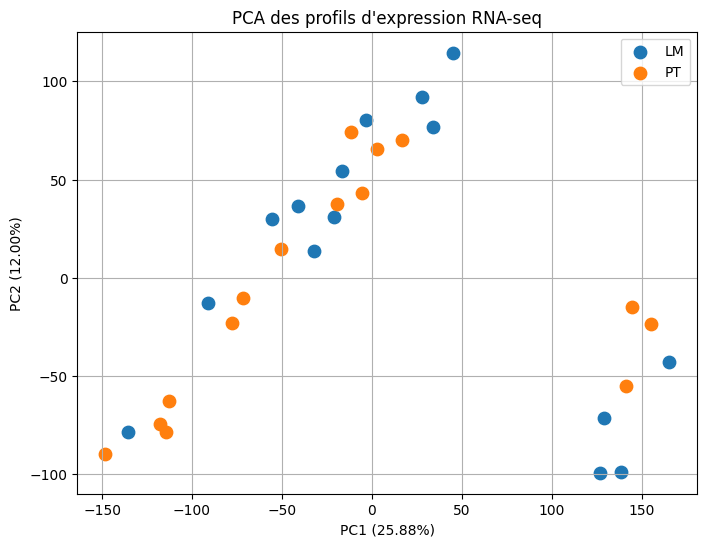

In [26]:
import matplotlib.pyplot as plt

samples = expression_T.index

groups = ['LM' if 'LM' in sample else 'PT' for sample in samples]

plt.figure(figsize=(8,6))

for group in ['LM', 'PT']:
    indices = [i for i, g in enumerate(groups) if g == group]
    
    plt.scatter(
        pca_result[indices,0],
        pca_result[indices,1],
        label=group,
        s=80
    )

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)")
plt.title("PCA des profils d'expression RNA-seq")
plt.legend()
plt.grid()
plt.show()

In [27]:
from sklearn.decomposition import PCA

pca_full = PCA(n_components=10)

pca_data = pca_full.fit_transform(scaled_expression)

print(pca_data.shape)

(30, 10)


In [28]:
print(pca_data.shape)

(30, 10)


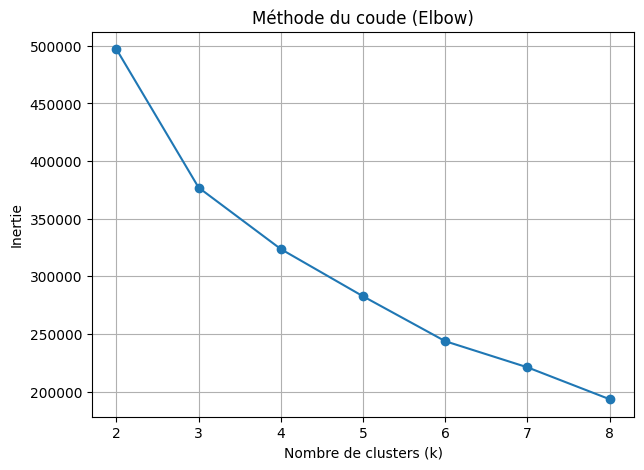

In [29]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

K = range(2,9)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(pca_data)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(7,5))
plt.plot(list(K), inertias, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude (Elbow)")
plt.grid()
plt.show()

In [30]:
import os

print("Dossier actuel :")
print(os.getcwd())

print("\nContenu du dossier data :")
print(os.listdir("../data"))

Dossier actuel :
C:\Users\Dell\Documents\Stage bioinfo\notebooks

Contenu du dossier data :
['.ipynb_checkpoints', 'GSE104178_family.soft.gz', 'GSE255163_family.soft.gz', 'GSE255163_RNAseq_count.csv.gz']


In [31]:
import pandas as pd

counts = pd.read_csv("../data/GSE255163_RNAseq_count.csv.gz")

print("Matrice chargée avec succès !")
print("Dimensions :", counts.shape)

Matrice chargée avec succès !
Dimensions : (59953, 32)


In [32]:
# Afficher les premières lignes
counts.head()

,Name,Description,Pt19LM,Pt20LM,Pt15LM,Pt16LM,Pt17LM,Pt01LM,Pt02LM,Pt06LM1,...,Pt17PT,Pt01PT,Pt02PT,Pt06PT,Pt05PT,Pt07PT,Pt08PT1,Pt08PT2,Pt10PT,Pt11PT
0,ENSG00000223972.5_2,DDX11L1,3,19,0,4,2,18,9,2,...,10,2,1,2,5,4,4,2,0,7
1,ENSG00000227232.5_2,WASH7P,1229,475,2469,1662,1789,199,478,292,...,426,277,460,309,460,333,681,599,238,350
2,ENSG00000243485.5_6,MIR1302-2HG,0,2,6,6,10,0,1,0,...,0,2,0,0,0,0,2,0,2,0
3,ENSG00000237613.2_3,FAM138A,1,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
4,ENSG00000268020.3_4,OR4G4P,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,4,0,0,0


In [33]:
# Informations sur les colonnes et les types
print(counts.info())

<class 'pandas.DataFrame'>
RangeIndex: 59953 entries, 0 to 59952
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Name         59953 non-null  str  
 1   Description  59953 non-null  str  
 2   Pt19LM       59953 non-null  int64
 3   Pt20LM       59953 non-null  int64
 4   Pt15LM       59953 non-null  int64
 5   Pt16LM       59953 non-null  int64
 6   Pt17LM       59953 non-null  int64
 7   Pt01LM       59953 non-null  int64
 8   Pt02LM       59953 non-null  int64
 9   Pt06LM1      59953 non-null  int64
 10  Pt06LM2      59953 non-null  int64
 11  Pt05LM1      59953 non-null  int64
 12  Pt05LM2      59953 non-null  int64
 13  Pt07LM       59953 non-null  int64
 14  Pt08LM       59953 non-null  int64
 15  Pt10LM       59953 non-null  int64
 16  Pt11LM       59953 non-null  int64
 17  Pt19PT       59953 non-null  int64
 18  Pt20PT       59953 non-null  int64
 19  Pt18PT       59953 non-null  int64
 20  Pt13PT       5995

In [34]:
# Noms des colonnes
print(counts.columns.tolist())

['Name', 'Description', 'Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM', 'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2', 'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT', 'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT', 'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT']


In [35]:
print(counts.iloc[:, :5].head())

                  Name  Description  Pt19LM  Pt20LM  Pt15LM
0  ENSG00000223972.5_2      DDX11L1       3      19       0
1  ENSG00000227232.5_2       WASH7P    1229     475    2469
2  ENSG00000243485.5_6  MIR1302-2HG       0       2       6
3  ENSG00000237613.2_3      FAM138A       1       0       0
4  ENSG00000268020.3_4       OR4G4P       0       0       0


In [36]:
print("Nombre de lignes :", len(counts))
print("Nombre de colonnes :", len(counts.columns))

Nombre de lignes : 59953
Nombre de colonnes : 32


In [37]:
counts.head()

,Name,Description,Pt19LM,Pt20LM,Pt15LM,Pt16LM,Pt17LM,Pt01LM,Pt02LM,Pt06LM1,...,Pt17PT,Pt01PT,Pt02PT,Pt06PT,Pt05PT,Pt07PT,Pt08PT1,Pt08PT2,Pt10PT,Pt11PT
0,ENSG00000223972.5_2,DDX11L1,3,19,0,4,2,18,9,2,...,10,2,1,2,5,4,4,2,0,7
1,ENSG00000227232.5_2,WASH7P,1229,475,2469,1662,1789,199,478,292,...,426,277,460,309,460,333,681,599,238,350
2,ENSG00000243485.5_6,MIR1302-2HG,0,2,6,6,10,0,1,0,...,0,2,0,0,0,0,2,0,2,0
3,ENSG00000237613.2_3,FAM138A,1,0,0,0,0,0,0,0,...,0,0,0,0,2,0,0,0,0,0
4,ENSG00000268020.3_4,OR4G4P,0,0,0,0,0,0,0,0,...,2,0,0,0,0,0,4,0,0,0


In [38]:
print(counts.columns.tolist())

['Name', 'Description', 'Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM', 'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2', 'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT', 'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT', 'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT']


In [39]:
import GEOparse

gse255163 = GEOparse.get_GEO(
    geo="GSE255163",
    destdir="../data"
)

print("GSE chargé :", gse255163.name)
print("Nombre d'échantillons :", len(gse255163.gsms))

13-Aug-2026 13:21:33 DEBUG utils - Directory ../data already exists. Skipping.
13-Aug-2026 13:21:33 INFO GEOparse - File already exist: using local version.
13-Aug-2026 13:21:33 INFO GEOparse - Parsing ../data\GSE255163_family.soft.gz: 
13-Aug-2026 13:21:33 DEBUG GEOparse - DATABASE: GeoMiame
13-Aug-2026 13:21:33 DEBUG GEOparse - SERIES: GSE255163
13-Aug-2026 13:21:33 DEBUG GEOparse - PLATFORM: GPL24676
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065059
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065060
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065061
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065062
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065063
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065064
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065065
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065066
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065067
13-Aug-2026 13:21:33 DEBUG GEOparse - SAMPLE: GSM8065068
13-Aug-2026 13:21:33 DE

GSE chargé : GSE255163
Nombre d'échantillons : 30


In [40]:
for gsm_id, gsm in gse255163.gsms.items():
    print("=" * 60)
    print("GSM :", gsm_id)
    
    if "characteristics_ch1" in gsm.metadata:
        for info in gsm.metadata["characteristics_ch1"]:
            print(info)

GSM : GSM8065059
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065060
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065061
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065062
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065063
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065064
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065065
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065066
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065067
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065068
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065069
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065070
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065071
tissue: tumor (liver metastasis of colorectal cancer)
GSM : GSM8065072
tissue: tumor (primary tumor of colorectal cancer)
GSM : GSM8065073
tissue:

In [41]:
for gsm_id, gsm in gse255163.gsms.items():
    print("=" * 60)
    print("GSM :", gsm_id)
    
    for key in ["title", "source_name_ch1", "characteristics_ch1"]:
        if key in gsm.metadata:
            print(key, ":", gsm.metadata[key])

GSM : GSM8065059
title : ['RNA-Seq - Pt01LM']
source_name_ch1 : ['tumor (liver metastasis of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (liver metastasis of colorectal cancer)']
GSM : GSM8065060
title : ['RNA-Seq - Pt01PT']
source_name_ch1 : ['tumor (primary tumor of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (primary tumor of colorectal cancer)']
GSM : GSM8065061
title : ['RNA-Seq - Pt02LM']
source_name_ch1 : ['tumor (liver metastasis of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (liver metastasis of colorectal cancer)']
GSM : GSM8065062
title : ['RNA-Seq - Pt02PT']
source_name_ch1 : ['tumor (primary tumor of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (primary tumor of colorectal cancer)']
GSM : GSM8065063
title : ['RNA-Seq - Pt05LM1']
source_name_ch1 : ['tumor (liver metastasis of colorectal cancer)']
characteristics_ch1 : ['tissue: tumor (liver metastasis of colorectal cancer)']
GSM : GSM8065064
title : ['RNA-Seq - Pt05

In [42]:
# Création des métadonnées à partir des noms des échantillons

sample_names = counts.columns[2:]

metadata = pd.DataFrame(index=sample_names)

metadata["Condition"] = [
    "Liver_Metastasis" if "LM" in sample else "Primary_Tumor"
    for sample in sample_names
]

metadata.head()

,Condition
Pt19LM,Liver_Metastasis
Pt20LM,Liver_Metastasis
Pt15LM,Liver_Metastasis
Pt16LM,Liver_Metastasis
Pt17LM,Liver_Metastasis


In [43]:
print(metadata["Condition"].value_counts())

Condition
Liver_Metastasis    15
Primary_Tumor       15
Name: count, dtype: int64


In [44]:
print("Nombre d'échantillons dans la matrice :", len(sample_names))
print("Nombre d'échantillons dans metadata :", len(metadata))

Nombre d'échantillons dans la matrice : 30
Nombre d'échantillons dans metadata : 30


In [45]:
print(metadata)

                Condition
Pt19LM   Liver_Metastasis
Pt20LM   Liver_Metastasis
Pt15LM   Liver_Metastasis
Pt16LM   Liver_Metastasis
Pt17LM   Liver_Metastasis
Pt01LM   Liver_Metastasis
Pt02LM   Liver_Metastasis
Pt06LM1  Liver_Metastasis
Pt06LM2  Liver_Metastasis
Pt05LM1  Liver_Metastasis
Pt05LM2  Liver_Metastasis
Pt07LM   Liver_Metastasis
Pt08LM   Liver_Metastasis
Pt10LM   Liver_Metastasis
Pt11LM   Liver_Metastasis
Pt19PT      Primary_Tumor
Pt20PT      Primary_Tumor
Pt18PT      Primary_Tumor
Pt13PT      Primary_Tumor
Pt15PT      Primary_Tumor
Pt17PT      Primary_Tumor
Pt01PT      Primary_Tumor
Pt02PT      Primary_Tumor
Pt06PT      Primary_Tumor
Pt05PT      Primary_Tumor
Pt07PT      Primary_Tumor
Pt08PT1     Primary_Tumor
Pt08PT2     Primary_Tumor
Pt10PT      Primary_Tumor
Pt11PT      Primary_Tumor


In [46]:
print(metadata["Condition"].value_counts())

Condition
Liver_Metastasis    15
Primary_Tumor       15
Name: count, dtype: int64


In [47]:
print("Nombre d'échantillons dans la matrice :", len(sample_names))
print("Nombre d'échantillons dans metadata :", len(metadata))

print("\nCorrespondance des noms :")
print(counts.columns[2:].equals(metadata.index))

Nombre d'échantillons dans la matrice : 30
Nombre d'échantillons dans metadata : 30

Correspondance des noms :
True


In [48]:
# Vérifier les types de données des échantillons

print(counts[sample_names].dtypes.value_counts())

int64    30
Name: count, dtype: int64


In [49]:
# Vérifier les valeurs manquantes

missing = counts[sample_names].isna().sum().sum()

print("Nombre total de valeurs manquantes :", missing)

Nombre total de valeurs manquantes : 0


In [50]:
# Vérifier les valeurs négatives

negative_values = (counts[sample_names] < 0).sum().sum()

print("Nombre de valeurs négatives :", negative_values)

Nombre de valeurs négatives : 0


In [51]:
# Vérifier si les comptages sont des nombres entiers

non_integer = (
    counts[sample_names] % 1 != 0
).sum().sum()

print("Nombre de valeurs non entières :", non_integer)

Nombre de valeurs non entières : 0


In [52]:
# Préparation de la matrice de comptages

count_matrix = counts.set_index("Name")[sample_names]

print("Dimensions de la matrice :", count_matrix.shape)
print(count_matrix.head())

Dimensions de la matrice : (59953, 30)
                     Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  Pt01LM  Pt02LM  \
Name                                                                          
ENSG00000223972.5_2       3      19       0       4       2      18       9   
ENSG00000227232.5_2    1229     475    2469    1662    1789     199     478   
ENSG00000243485.5_6       0       2       6       6      10       0       1   
ENSG00000237613.2_3       1       0       0       0       0       0       0   
ENSG00000268020.3_4       0       0       0       0       0       0       0   

                     Pt06LM1  Pt06LM2  Pt05LM1  ...  Pt17PT  Pt01PT  Pt02PT  \
Name                                            ...                           
ENSG00000223972.5_2        2        8        8  ...      10       2       1   
ENSG00000227232.5_2      292      243      324  ...     426     277     460   
ENSG00000243485.5_6        0        0        2  ...       0       2       0   
ENSG00000237

In [53]:
# Vérifier les identifiants de gènes dupliqués

print("Nombre total de lignes :", len(count_matrix))
print("Nombre d'identifiants uniques :", count_matrix.index.nunique())
print("Nombre de doublons :", count_matrix.index.duplicated().sum())

Nombre total de lignes : 59953
Nombre d'identifiants uniques : 59953
Nombre de doublons : 0


In [54]:
# Filtrage des gènes faiblement exprimés

min_count = 10
min_samples = 3

keep_genes = (count_matrix >= min_count).sum(axis=1) >= min_samples

count_matrix_filtered = count_matrix[keep_genes]

print("Nombre de gènes avant filtrage :", count_matrix.shape[0])
print("Nombre de gènes après filtrage :", count_matrix_filtered.shape[0])
print("Nombre de gènes supprimés :", 
      count_matrix.shape[0] - count_matrix_filtered.shape[0])

Nombre de gènes avant filtrage : 59953
Nombre de gènes après filtrage : 29182
Nombre de gènes supprimés : 30771


In [55]:
print("Dimensions après filtrage :", count_matrix_filtered.shape)

Dimensions après filtrage : (29182, 30)


In [56]:
print(count_matrix_filtered.head())

                     Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  Pt01LM  Pt02LM  \
Name                                                                          
ENSG00000223972.5_2       3      19       0       4       2      18       9   
ENSG00000227232.5_2    1229     475    2469    1662    1789     199     478   
ENSG00000238009.6_8       3      15       5      20      18       0       2   
ENSG00000233750.3_4      47      34      25      22      42      18       5   
ENSG00000237683.5      1544     241     420    1004    1117     142      25   

                     Pt06LM1  Pt06LM2  Pt05LM1  ...  Pt17PT  Pt01PT  Pt02PT  \
Name                                            ...                           
ENSG00000223972.5_2        2        8        8  ...      10       2       1   
ENSG00000227232.5_2      292      243      324  ...     426     277     460   
ENSG00000238009.6_8        4        3        5  ...      10       4       6   
ENSG00000233750.3_4       18        9       14  ...

In [57]:
print(metadata.head())

               Condition
Pt19LM  Liver_Metastasis
Pt20LM  Liver_Metastasis
Pt15LM  Liver_Metastasis
Pt16LM  Liver_Metastasis
Pt17LM  Liver_Metastasis


In [58]:
print("Dimensions après filtrage :", count_matrix_filtered.shape)
print(count_matrix_filtered.head())
print(metadata.head())

Dimensions après filtrage : (29182, 30)
                     Pt19LM  Pt20LM  Pt15LM  Pt16LM  Pt17LM  Pt01LM  Pt02LM  \
Name                                                                          
ENSG00000223972.5_2       3      19       0       4       2      18       9   
ENSG00000227232.5_2    1229     475    2469    1662    1789     199     478   
ENSG00000238009.6_8       3      15       5      20      18       0       2   
ENSG00000233750.3_4      47      34      25      22      42      18       5   
ENSG00000237683.5      1544     241     420    1004    1117     142      25   

                     Pt06LM1  Pt06LM2  Pt05LM1  ...  Pt17PT  Pt01PT  Pt02PT  \
Name                                            ...                           
ENSG00000223972.5_2        2        8        8  ...      10       2       1   
ENSG00000227232.5_2      292      243      324  ...     426     277     460   
ENSG00000238009.6_8        4        3        5  ...      10       4       6   
ENSG0000023

In [60]:
print("Nombre total d'échantillons :", len(metadata))

print("\nRépartition des groupes :")
print(metadata["Condition"].value_counts())

Nombre total d'échantillons : 30

Répartition des groupes :
Condition
Liver_Metastasis    15
Primary_Tumor       15
Name: count, dtype: int64


In [61]:
print(metadata.columns.tolist())


['Condition']


In [62]:
print("Nombre total d'échantillons :", len(metadata))

print("\nRépartition des groupes :")
print(metadata["Condition"].value_counts())

Nombre total d'échantillons : 30

Répartition des groupes :
Condition
Liver_Metastasis    15
Primary_Tumor       15
Name: count, dtype: int64


In [63]:
print("Dimensions de count_matrix :", count_matrix.shape)
print("Nombre d'échantillons dans metadata :", len(metadata))

Dimensions de count_matrix : (59953, 30)
Nombre d'échantillons dans metadata : 30


In [64]:
print("Échantillons dans count_matrix :")
print(count_matrix.columns.tolist())

print("\nÉchantillons dans metadata :")
print(metadata.index.tolist())

Échantillons dans count_matrix :
['Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM', 'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2', 'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT', 'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT', 'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT']

Échantillons dans metadata :
['Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM', 'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2', 'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT', 'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT', 'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT']


In [65]:
print("Dimensions de la matrice filtrée :", count_matrix_filtered.shape)

Dimensions de la matrice filtrée : (29182, 30)


In [66]:
import importlib.util

print("PyDESeq2 :", importlib.util.find_spec("pydeseq2"))

PyDESeq2 : ModuleSpec(name='pydeseq2', loader=<_frozen_importlib_external.SourceFileLoader object at 0x0000023582F37770>, origin='C:\\Users\\Dell\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\pydeseq2\\__init__.py', submodule_search_locations=['C:\\Users\\Dell\\AppData\\Local\\Programs\\Python\\Python314\\Lib\\site-packages\\pydeseq2'])


In [67]:
print(metadata.head())
print("\nIndex des métadonnées :")
print(metadata.index.tolist())

print("\nColonnes :")
print(metadata.columns.tolist())

               Condition
Pt19LM  Liver_Metastasis
Pt20LM  Liver_Metastasis
Pt15LM  Liver_Metastasis
Pt16LM  Liver_Metastasis
Pt17LM  Liver_Metastasis

Index des métadonnées :
['Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM', 'Pt01LM', 'Pt02LM', 'Pt06LM1', 'Pt06LM2', 'Pt05LM1', 'Pt05LM2', 'Pt07LM', 'Pt08LM', 'Pt10LM', 'Pt11LM', 'Pt19PT', 'Pt20PT', 'Pt18PT', 'Pt13PT', 'Pt15PT', 'Pt17PT', 'Pt01PT', 'Pt02PT', 'Pt06PT', 'Pt05PT', 'Pt07PT', 'Pt08PT1', 'Pt08PT2', 'Pt10PT', 'Pt11PT']

Colonnes :
['Condition']


In [68]:
print("Même ordre des échantillons :",
      list(count_matrix_filtered.columns) == list(metadata.index))

print("\nNombre de colonnes de count_matrix_filtered :",
      count_matrix_filtered.shape[1])

print("Nombre de lignes de metadata :",
      metadata.shape[0])

Même ordre des échantillons : True

Nombre de colonnes de count_matrix_filtered : 30
Nombre de lignes de metadata : 30


In [69]:
from pydeseq2.dds import DeseqDataSet

# PyDESeq2 attend :
# lignes = échantillons
# colonnes = gènes
counts = count_matrix_filtered.T.copy()

print("Dimensions de counts :", counts.shape)
print("\nPremiers échantillons :")
print(counts.index[:5])

print("\nNombre de gènes :", counts.shape[1])
print("Nombre d'échantillons :", counts.shape[0])

Dimensions de counts : (30, 29182)

Premiers échantillons :
Index(['Pt19LM', 'Pt20LM', 'Pt15LM', 'Pt16LM', 'Pt17LM'], dtype='str')

Nombre de gènes : 29182
Nombre d'échantillons : 30


In [70]:
from pydeseq2.dds import DeseqDataSet

dds = DeseqDataSet(
    counts=counts,
    metadata=metadata,
    design_factors="Condition"
)

print("Objet PyDESeq2 créé avec succès.")

Objet PyDESeq2 créé avec succès.


C:\Users\Dell\AppData\Local\Temp\ipykernel_17500\308864320.py:3: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(


In [71]:
dds.deseq2()

Fitting size factors...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.27 seconds.

Fitting dispersions...
... done in 167.80 seconds.

Fitting dispersion trend curve...
... done in 10.56 seconds.

Fitting MAP dispersions...
... done in 395.21 seconds.

Fitting LFCs...
... done in 109.87 seconds.

Calculating cook's distance...
... done in 0.36 seconds.

Replacing 900 outlier genes.

Fitting dispersions...
... done in 4.32 seconds.

Fitting MAP dispersions...
... done in 4.72 seconds.

Fitting LFCs...
... done in 5.06 seconds.



In [79]:
print("Facteurs de taille :")
print(dds.obs["size_factors"])

print("\nRésumé :")
print(dds.obs["size_factors"].describe())

Facteurs de taille :
Pt19LM     0.930319
Pt20LM     0.826473
Pt15LM     1.406408
Pt16LM     1.122172
Pt17LM     1.234801
Pt01LM     0.834324
Pt02LM     1.231160
Pt06LM1    1.058677
Pt06LM2    1.077644
Pt05LM1    1.130910
Pt05LM2    1.166625
Pt07LM     1.015903
Pt08LM     0.938961
Pt10LM     1.081466
Pt11LM     1.031874
Pt19PT     1.770977
Pt20PT     0.665527
Pt18PT     1.360697
Pt13PT     1.305863
Pt15PT     0.942482
Pt17PT     0.780393
Pt01PT     0.947273
Pt02PT     0.810199
Pt06PT     0.992165
Pt05PT     1.058950
Pt07PT     0.762726
Pt08PT1    0.980882
Pt08PT2    0.622554
Pt10PT     1.107289
Pt11PT     1.087739
Name: size_factors, dtype: float64

Résumé :
count    30.000000
mean      1.042781
std       0.235205
min       0.622554
25%       0.932480
50%       1.045276
75%       1.128725
max       1.770977
Name: size_factors, dtype: float64


In [75]:
print(dds)

AnnData object with n_obs × n_vars = 30 × 29182
    obs: 'Condition', 'size_factors', 'replaceable'
    var: '_normed_means', 'non_zero', '_MoM_dispersions', 'genewise_dispersions', '_genewise_converged', 'fitted_dispersions', 'MAP_dispersions', '_MAP_converged', 'dispersions', '_outlier_genes', '_LFC_converged', 'replaced', 'refitted', '_pvalue_cooks_outlier'
    uns: 'trend_coeffs', 'disp_function_type', '_squared_logres', 'prior_disp_var'
    obsm: 'design_matrix', '_mu_LFC', '_hat_diagonals'
    varm: 'LFC'
    layers: None (.X), 'normed_counts', '_mu_hat', 'cooks', 'replace_cooks'


In [76]:
print("TES")


TES


In [77]:
print("TEST")
print(count_matrix_filtered.shape)
print(metadata.shape)

TEST
(29182, 30)
(30, 1)


In [78]:
count_matrix_filtered.to_csv("count_matrix_filtered.csv")
metadata.to_csv("metadata.csv")

print("Données sauvegardées avec succès.")

Données sauvegardées avec succès.


In [80]:
print("Conditions utilisées :")
print(dds.obs["Condition"].value_counts())

print("\nNiveaux de référence :")
print(dds.obs["Condition"].unique())

Conditions utilisées :
Condition
Liver_Metastasis    15
Primary_Tumor       15
Name: count, dtype: int64

Niveaux de référence :
<StringArray>
['Liver_Metastasis', 'Primary_Tumor']
Length: 2, dtype: str


In [81]:
print("Matrice de design :")
print(dds.obsm["design_matrix"])

print("\nColonnes de la matrice de design :")
print(dds.obsm["design_matrix"].columns)

Matrice de design :
         Intercept  Condition[T.Primary_Tumor]
Pt19LM         1.0                           0
Pt20LM         1.0                           0
Pt15LM         1.0                           0
Pt16LM         1.0                           0
Pt17LM         1.0                           0
Pt01LM         1.0                           0
Pt02LM         1.0                           0
Pt06LM1        1.0                           0
Pt06LM2        1.0                           0
Pt05LM1        1.0                           0
Pt05LM2        1.0                           0
Pt07LM         1.0                           0
Pt08LM         1.0                           0
Pt10LM         1.0                           0
Pt11LM         1.0                           0
Pt19PT         1.0                           1
Pt20PT         1.0                           1
Pt18PT         1.0                           1
Pt13PT         1.0                           1
Pt15PT         1.0                      

In [82]:
results = dds.results_df

print("Dimensions des résultats :", results.shape)

print("\nColonnes disponibles :")
print(results.columns.tolist())

print("\nPremières lignes :")
print(results.head())

AttributeError: 'DeseqDataSet' object has no attribute 'results_df'

In [83]:
from pydeseq2.ds import DeseqStats

stat_res = DeseqStats(
    dds,
    contrast=["Condition", "Primary_Tumor", "Liver_Metastasis"]
)

stat_res.summary()

Running Wald tests...
... done in 37.36 seconds.



Log2 fold change & Wald test p-value: Condition Primary_Tumor vs Liver_Metastasis
                          baseMean  log2FoldChange     lfcSE      stat  \
Name                                                                     
ENSG00000223972.5_2       4.875559       -0.506028  0.756363 -0.669028   
ENSG00000227232.5_2     644.365918        0.044907  0.363272  0.123619   
ENSG00000238009.6_8       6.324963        0.074261  0.517717  0.143439   
ENSG00000233750.3_4      19.615251       -0.011982  0.416751 -0.028751   
ENSG00000237683.5       280.720211       -0.596377  0.496802 -1.200432   
...                            ...             ...       ...       ...   
ENSG00000212907.2_1   56705.743737        0.040347  0.454107  0.088850   
ENSG00000198886.2_1  686676.501732       -0.560061  0.541823 -1.033660   
ENSG00000198786.2_1  184306.024331       -0.260023  0.436241 -0.596054   
ENSG00000198695.2_1   64237.554747       -0.500283  0.532093 -0.940216   
ENSG00000198727.2_1  283815.50

In [84]:
results = stat_res.results_df

significant = results[
    results["padj"] < 0.05
]

print("Nombre de gènes significatifs :", len(significant))

Nombre de gènes significatifs : 1181


In [85]:
up_primary = significant[
    significant["log2FoldChange"] > 0
]

up_metastasis = significant[
    significant["log2FoldChange"] < 0
]

print("Gènes plus exprimés dans Primary_Tumor :", len(up_primary))
print("Gènes plus exprimés dans Liver_Metastasis :", len(up_metastasis))

Gènes plus exprimés dans Primary_Tumor : 463
Gènes plus exprimés dans Liver_Metastasis : 718


In [86]:
top_primary = up_primary.sort_values(
    "log2FoldChange",
    ascending=False
).head(10)

top_metastasis = up_metastasis.sort_values(
    "log2FoldChange",
    ascending=True
).head(10)

print("=== Top 10 Primary_Tumor ===")
print(top_primary[["baseMean", "log2FoldChange", "pvalue", "padj"]])

print("\n=== Top 10 Liver_Metastasis ===")
print(top_metastasis[["baseMean", "log2FoldChange", "pvalue", "padj"]])

=== Top 10 Primary_Tumor ===
                         baseMean  log2FoldChange        pvalue          padj
Name                                                                         
ENSG00000162670.11_4    32.889215        8.180851  1.219928e-07  9.699924e-06
ENSG00000119919.11_3   107.584730        7.169118  2.957598e-44  8.630566e-41
ENSG00000149968.12_3  1835.059261        6.391624  1.799086e-25  7.094478e-23
ENSG00000079841.18_4    11.810611        6.300213  4.561420e-10  4.893632e-08
ENSG00000163873.10_4    46.110979        6.239998  7.057943e-30  3.677818e-27
ENSG00000172987.12_3    30.857081        6.144965  7.308222e-21  2.132612e-18
ENSG00000198597.9_5     63.219081        6.101388  6.378919e-18  1.454244e-15
ENSG00000172554.12_3     6.901208        5.899632  6.031096e-10  6.353553e-08
ENSG00000156687.11_5    11.523072        5.866390  5.451398e-08  4.558088e-06
ENSG00000134121.10_5   212.464746        5.839441  4.533314e-28  2.133655e-25

=== Top 10 Liver_Metastasis ===
  

In [87]:
import numpy as np

results_plot = results.copy()

results_plot["-log10_padj"] = -np.log10(
    results_plot["padj"].clip(lower=1e-300)
)

results_plot["significance"] = "Non significatif"

results_plot.loc[
    (results_plot["padj"] < 0.05) &
    (results_plot["log2FoldChange"] > 0),
    "significance"
] = "Primary_Tumor"

results_plot.loc[
    (results_plot["padj"] < 0.05) &
    (results_plot["log2FoldChange"] < 0),
    "significance"
] = "Liver_Metastasis"

print(results_plot["significance"].value_counts())

significance
Non significatif    28001
Liver_Metastasis      718
Primary_Tumor         463
Name: count, dtype: int64


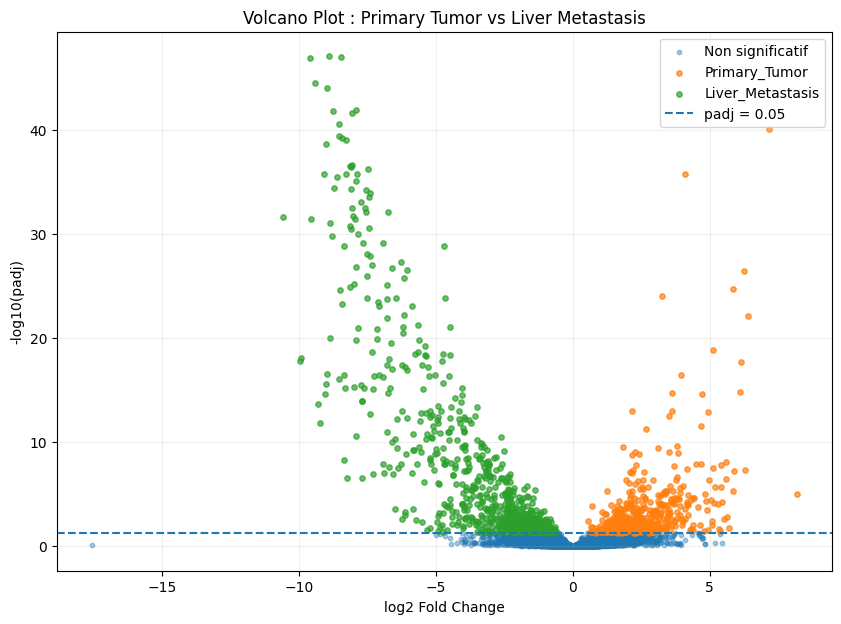

In [88]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Gènes non significatifs
non_sig = results_plot["significance"] == "Non significatif"

plt.scatter(
    results_plot.loc[non_sig, "log2FoldChange"],
    results_plot.loc[non_sig, "-log10_padj"],
    alpha=0.4,
    s=10,
    label="Non significatif"
)

# Gènes plus exprimés dans Primary_Tumor
primary = results_plot["significance"] == "Primary_Tumor"

plt.scatter(
    results_plot.loc[primary, "log2FoldChange"],
    results_plot.loc[primary, "-log10_padj"],
    alpha=0.7,
    s=15,
    label="Primary_Tumor"
)

# Gènes plus exprimés dans Liver_Metastasis
metastasis = results_plot["significance"] == "Liver_Metastasis"

plt.scatter(
    results_plot.loc[metastasis, "log2FoldChange"],
    results_plot.loc[metastasis, "-log10_padj"],
    alpha=0.7,
    s=15,
    label="Liver_Metastasis"
)

# Ligne correspondant à padj = 0.05
import numpy as np

plt.axhline(
    -np.log10(0.05),
    linestyle="--",
    label="padj = 0.05"
)

plt.xlabel("log2 Fold Change")
plt.ylabel("-log10(padj)")
plt.title("Volcano Plot : Primary Tumor vs Liver Metastasis")
plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [89]:
# Top 10 gènes Primary_Tumor
top_primary = (
    up_primary
    .sort_values("log2FoldChange", ascending=False)
    .head(10)
)

# Top 10 gènes Liver_Metastasis
top_metastasis = (
    up_metastasis
    .sort_values("log2FoldChange", ascending=True)
    .head(10)
)

# Combinaison des 20 gènes
top_genes = list(top_primary.index) + list(top_metastasis.index)

print("Nombre de gènes sélectionnés :", len(top_genes))
print("\nGènes sélectionnés :")
for gene in top_genes:
    print(gene)

Nombre de gènes sélectionnés : 20

Gènes sélectionnés :
ENSG00000162670.11_4
ENSG00000119919.11_3
ENSG00000149968.12_3
ENSG00000079841.18_4
ENSG00000163873.10_4
ENSG00000172987.12_3
ENSG00000198597.9_5
ENSG00000172554.12_3
ENSG00000156687.11_5
ENSG00000134121.10_5
ENSG00000101981.11_4
ENSG00000134389.9_2
ENSG00000072080.11_6
ENSG00000132693.12_3
ENSG00000165471.6_2
ENSG00000132703.4_3
ENSG00000267391.5_7
ENSG00000263761.2_2
ENSG00000021852.13_4
ENSG00000110244.7_3


In [90]:
# Récupérer les comptes normalisés calculés par PyDESeq2
norm_counts = dds.layers["normed_counts"]

# Convertir en DataFrame
norm_counts_df = pd.DataFrame(
    norm_counts,
    index=dds.obs_names,
    columns=dds.var_names
)

# Sélectionner les 20 gènes
heatmap_data = norm_counts_df[top_genes].copy()

print("Dimensions des données pour la heatmap :", heatmap_data.shape)
print(heatmap_data.head())

Dimensions des données pour la heatmap : (30, 20)
Name    ENSG00000162670.11_4  ENSG00000119919.11_3  ENSG00000149968.12_3  \
Pt19LM                   0.0              2.149799             10.748997   
Pt20LM                   0.0              0.000000              7.259766   
Pt15LM                   0.0              4.266187              9.954436   
Pt16LM                   0.0              1.782259             25.842750   
Pt17LM                   0.0              3.239388              4.049235   

Name    ENSG00000079841.18_4  ENSG00000163873.10_4  ENSG00000172987.12_3  \
Pt19LM                   0.0              2.149799              0.000000   
Pt20LM                   0.0              0.000000              0.000000   
Pt15LM                   0.0              1.422062              0.000000   
Pt16LM                   0.0              1.782259              0.000000   
Pt17LM                   0.0              0.000000              4.859082   

Name    ENSG00000198597.9_5  ENSG000

In [91]:
print(heatmap_data.shape)

(30, 20)


In [92]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Standardisation de chaque gène
scaler = StandardScaler()

heatmap_scaled = pd.DataFrame(
    scaler.fit_transform(heatmap_data),
    index=heatmap_data.index,
    columns=heatmap_data.columns
)

print("Dimensions :", heatmap_scaled.shape)
print(heatmap_scaled.head())

Dimensions : (30, 20)
Name    ENSG00000162670.11_4  ENSG00000119919.11_3  ENSG00000149968.12_3  \
Pt19LM             -0.428309             -0.703085             -0.432151   
Pt20LM             -0.428309             -0.717421             -0.432977   
Pt15LM             -0.428309             -0.688972             -0.432339   
Pt16LM             -0.428309             -0.705536             -0.428575   
Pt17LM             -0.428309             -0.695819             -0.433738   

Name    ENSG00000079841.18_4  ENSG00000163873.10_4  ENSG00000172987.12_3  \
Pt19LM             -0.541919             -0.738041             -0.634725   
Pt20LM             -0.541919             -0.774133             -0.634725   
Pt15LM             -0.541919             -0.750259             -0.634725   
Pt16LM             -0.541919             -0.744212             -0.634725   
Pt17LM             -0.541919             -0.774133             -0.534774   

Name    ENSG00000198597.9_5  ENSG00000172554.12_3  ENSG000001566

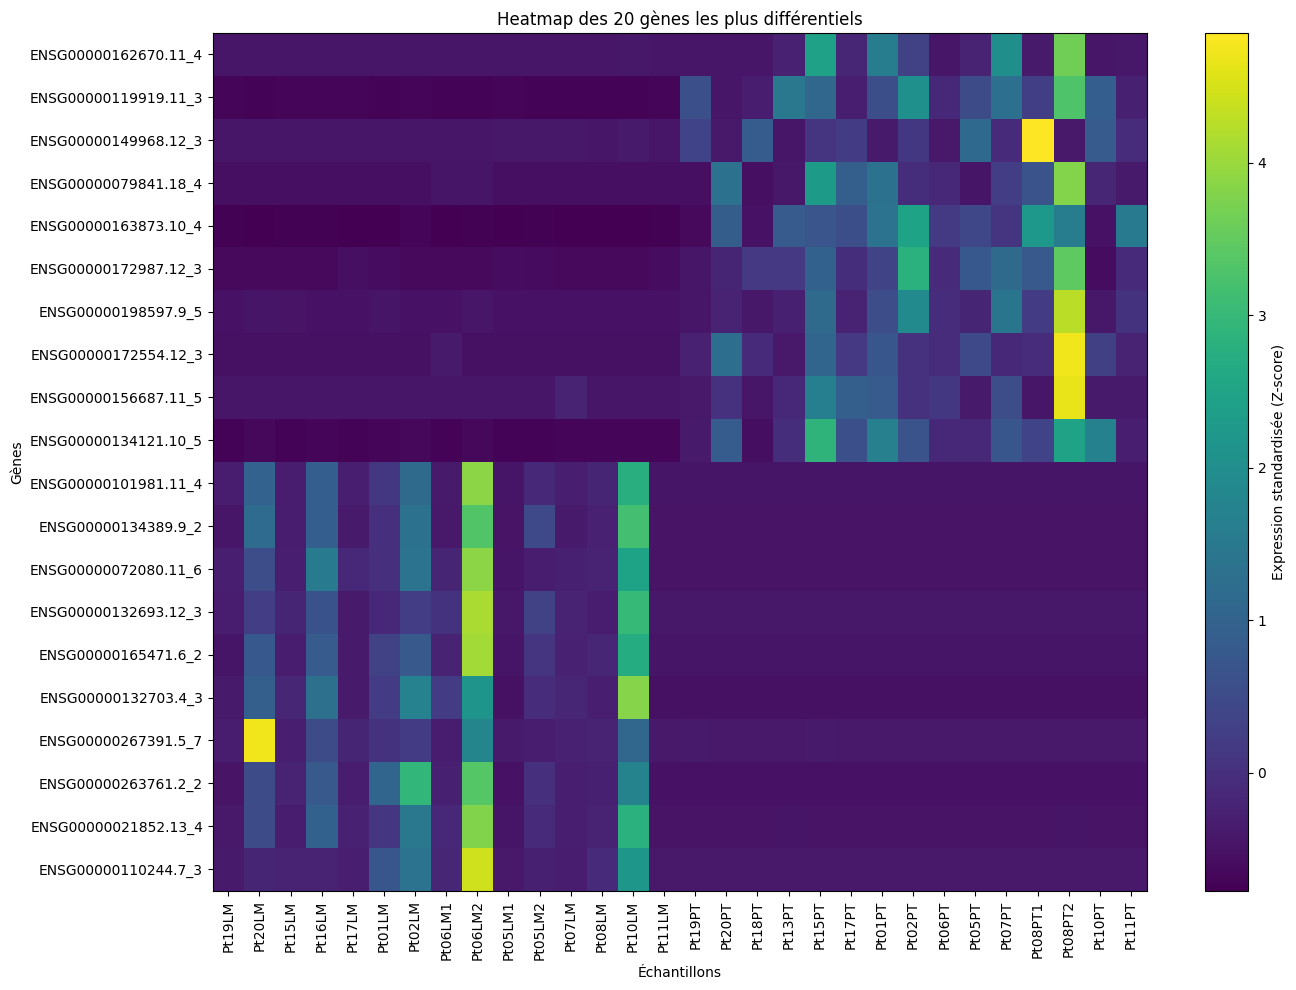

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))

plt.imshow(
    heatmap_scaled.T,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Expression standardisée (Z-score)")

plt.xticks(
    range(len(heatmap_scaled.index)),
    heatmap_scaled.index,
    rotation=90
)

plt.yticks(
    range(len(heatmap_scaled.columns)),
    heatmap_scaled.columns
)

plt.xlabel("Échantillons")
plt.ylabel("Gènes")
plt.title("Heatmap des 20 gènes les plus différentiels")

plt.tight_layout()
plt.show()

In [94]:
print(metadata.head())
print(metadata["Condition"].value_counts())

               Condition
Pt19LM  Liver_Metastasis
Pt20LM  Liver_Metastasis
Pt15LM  Liver_Metastasis
Pt16LM  Liver_Metastasis
Pt17LM  Liver_Metastasis
Condition
Liver_Metastasis    15
Primary_Tumor       15
Name: count, dtype: int64


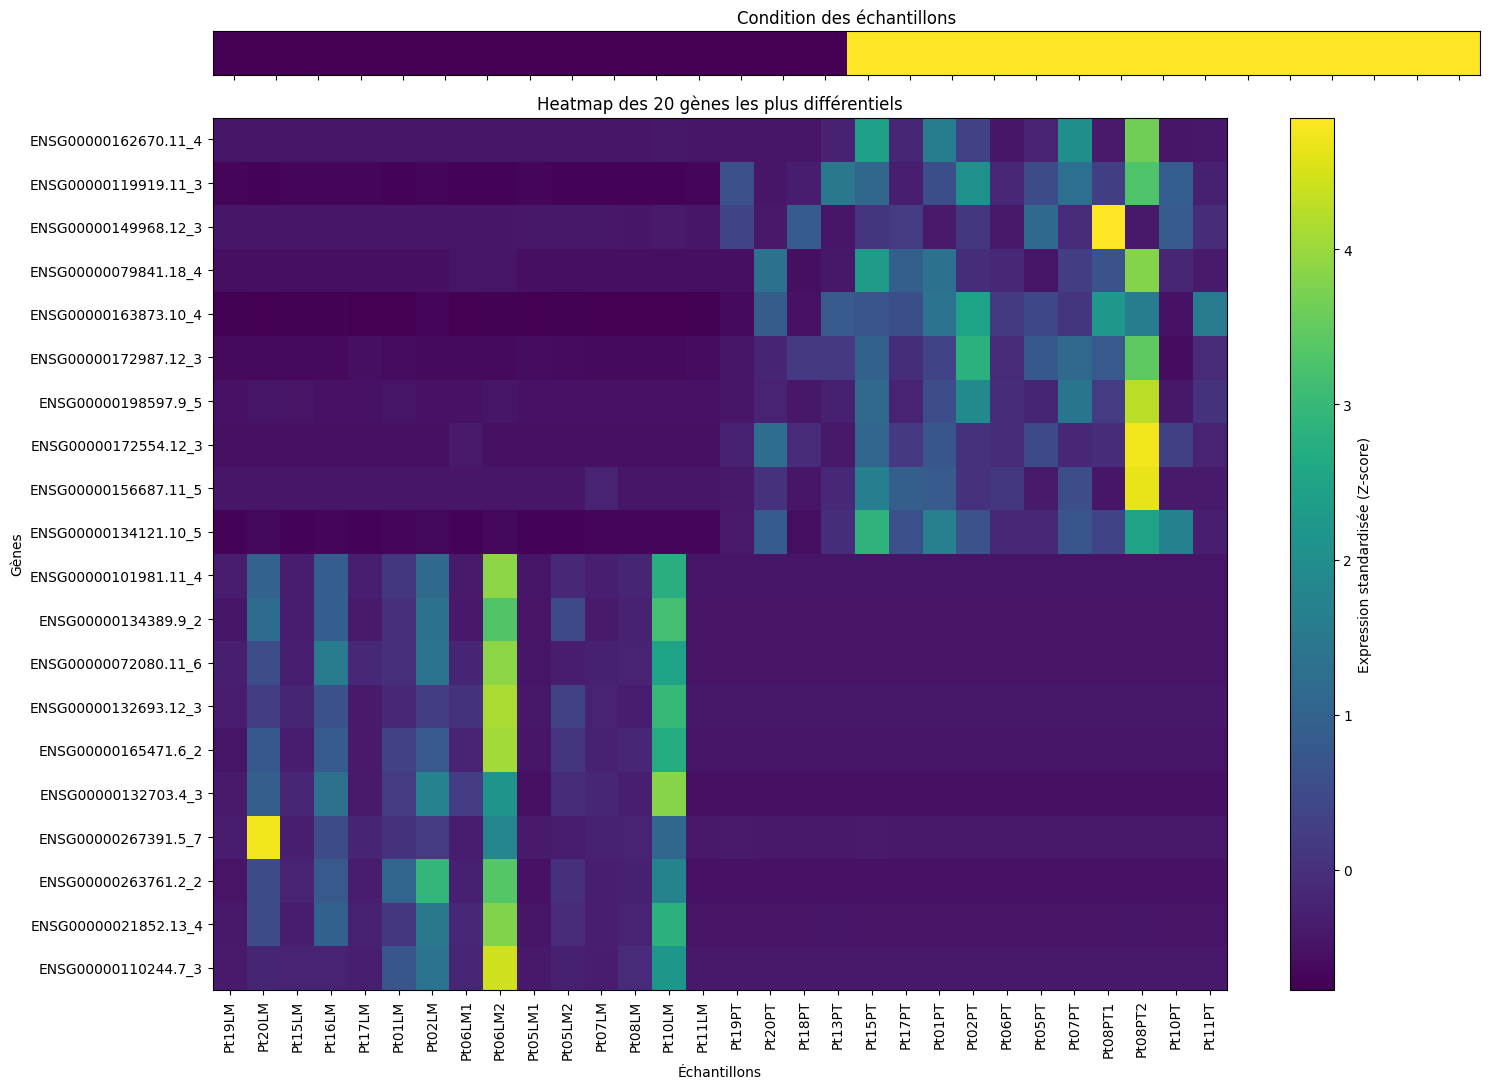

In [95]:
import matplotlib.pyplot as plt
import numpy as np

# Récupérer les conditions dans le même ordre que les échantillons
conditions = metadata.loc[heatmap_scaled.index, "Condition"]

# Transformer les conditions en valeurs numériques
condition_values = conditions.map({
    "Liver_Metastasis": 0,
    "Primary_Tumor": 1
}).values

fig, (ax_condition, ax_heatmap) = plt.subplots(
    2, 1,
    figsize=(15, 11),
    gridspec_kw={"height_ratios": [0.5, 10]},
    sharex=True
)

# Annotation des groupes
ax_condition.imshow(
    condition_values.reshape(1, -1),
    aspect="auto",
    interpolation="nearest"
)

ax_condition.set_yticks([])
ax_condition.set_title("Condition des échantillons")

ax_condition.set_xticks([])
    
# Heatmap
im = ax_heatmap.imshow(
    heatmap_scaled.T,
    aspect="auto",
    interpolation="nearest"
)

ax_heatmap.set_yticks(range(len(heatmap_scaled.columns)))
ax_heatmap.set_yticklabels(heatmap_scaled.columns)

ax_heatmap.set_xticks(range(len(heatmap_scaled.index)))
ax_heatmap.set_xticklabels(
    heatmap_scaled.index,
    rotation=90
)

ax_heatmap.set_xlabel("Échantillons")
ax_heatmap.set_ylabel("Gènes")
ax_heatmap.set_title("Heatmap des 20 gènes les plus différentiels")

fig.colorbar(
    im,
    ax=ax_heatmap,
    label="Expression standardisée (Z-score)"
)

plt.tight_layout()
plt.show()

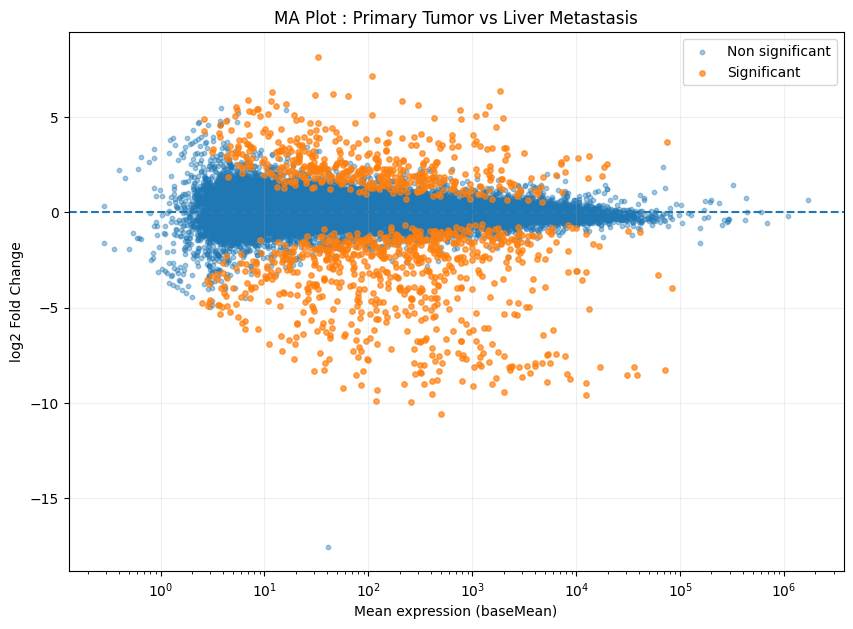

In [96]:
import matplotlib.pyplot as plt
import numpy as np

# نسخ النتائج
ma_data = results.copy()

# تحديد الجينات المهمة
ma_data["significance"] = "Non significant"

ma_data.loc[
    ma_data["padj"] < 0.05,
    "significance"
] = "Significant"

# إنشاء الرسم
plt.figure(figsize=(10, 7))

# الجينات غير المهمة
non_sig = ma_data["significance"] == "Non significant"

plt.scatter(
    ma_data.loc[non_sig, "baseMean"],
    ma_data.loc[non_sig, "log2FoldChange"],
    s=10,
    alpha=0.4,
    label="Non significant"
)

# الجينات المهمة
sig = ma_data["significance"] == "Significant"

plt.scatter(
    ma_data.loc[sig, "baseMean"],
    ma_data.loc[sig, "log2FoldChange"],
    s=15,
    alpha=0.7,
    label="Significant"
)

# Ligne horizontale à 0
plt.axhline(
    0,
    linestyle="--"
)

# Échelle logarithmique pour l'expression
plt.xscale("log")

plt.xlabel("Mean expression (baseMean)")
plt.ylabel("log2 Fold Change")
plt.title("MA Plot : Primary Tumor vs Liver Metastasis")

plt.legend()
plt.grid(alpha=0.2)

plt.show()

In [97]:
# Sauvegarder tous les résultats de l'analyse différentielle

results.to_csv("differential_expression_results.csv")

print("Résultats de l'analyse différentielle sauvegardés avec succès.")
print("Nombre de gènes :", results.shape[0])

Résultats de l'analyse différentielle sauvegardés avec succès.
Nombre de gènes : 29182


In [98]:
# Sélection des gènes significatifs

significant_genes = results[
    results["padj"] < 0.05
].copy()

significant_genes.to_csv(
    "significant_genes.csv"
)

print("Gènes significatifs sauvegardés avec succès.")
print("Nombre de gènes significatifs :", significant_genes.shape[0])

Gènes significatifs sauvegardés avec succès.
Nombre de gènes significatifs : 1181


In [99]:
primary_genes = significant_genes[
    significant_genes["log2FoldChange"] > 0
].copy()

primary_genes.to_csv(
    "genes_up_Primary_Tumor.csv"
)

print(
    "Gènes plus exprimés dans Primary_Tumor :",
    len(primary_genes)
)

Gènes plus exprimés dans Primary_Tumor : 463


In [100]:
metastasis_genes = significant_genes[
    significant_genes["log2FoldChange"] < 0
].copy()

metastasis_genes.to_csv(
    "genes_up_Liver_Metastasis.csv"
)

print(
    "Gènes plus exprimés dans Liver_Metastasis :",
    len(metastasis_genes)
)

Gènes plus exprimés dans Liver_Metastasis : 718


In [101]:
import os

files = [
    "count_matrix_filtered.csv",
    "metadata.csv",
    "differential_expression_results.csv",
    "significant_genes.csv",
    "genes_up_Primary_Tumor.csv",
    "genes_up_Liver_Metastasis.csv"
]

print("Fichiers disponibles :")

for file in files:
    print(
        file,
        "→",
        "OK" if os.path.exists(file) else "MANQUANT"
    )

Fichiers disponibles :
count_matrix_filtered.csv → OK
metadata.csv → OK
differential_expression_results.csv → OK
significant_genes.csv → OK
genes_up_Primary_Tumor.csv → OK
genes_up_Liver_Metastasis.csv → OK


In [102]:
print("========== RÉSUMÉ SEMAINE 2 ==========")

print("Nombre total d'échantillons :", len(metadata))
print("  - Liver_Metastasis :", 
      (metadata["Condition"] == "Liver_Metastasis").sum())
print("  - Primary_Tumor :", 
      (metadata["Condition"] == "Primary_Tumor").sum())

print("\nNombre de gènes après filtrage :", 
      count_matrix_filtered.shape[0])

print("Nombre de gènes analysés :", 
      results.shape[0])

print("Nombre de gènes significatifs :", 
      len(significant_genes))

print("Plus exprimés dans Primary_Tumor :", 
      len(primary_genes))

print("Plus exprimés dans Liver_Metastasis :", 
      len(metastasis_genes))

print("\n======================================")
print("Semaine 2 terminée avec succès.")

========== RÉSUMÉ SEMAINE 2 ==========
Nombre total d'échantillons : 30
  - Liver_Metastasis : 15
  - Primary_Tumor : 15

Nombre de gènes après filtrage : 29182
Nombre de gènes analysés : 29182
Nombre de gènes significatifs : 1181
Plus exprimés dans Primary_Tumor : 463
Plus exprimés dans Liver_Metastasis : 718

Semaine 2 terminée avec succès.
